# LangGraph research with independent critique and revision

A copy of the research walkthrough using the updated, shared research graph. The analyst proposes only supported views; an independent critic challenges them; a revision agent can keep, modify, merge same-asset proposals, reduce confidence, or abandon views. An empty final set is valid. Deterministic validation runs after feedback, then the **unchanged BL recipe runner** constructs the portfolio.

No backtest. This notebook is unexecuted. Set OPENAI_API_KEY through your environment or local .env, not a cell. Invocation makes three LLM calls for one cycle, or at most five for two cycles, before deterministic BL optimization. The critic has a separate prompt and no shared conversation history.

EPS and rates are synthetic; date filtering is not publication-time certification. MAX_ANNUAL_ALPHA is illustrative, not an empirically estimated forecast.

## 1. Imports and inputs
Edit the hypothesis, universe, cutoff, and revision limit (1 or 2).

In [3]:
import sys
from datetime import date
from pathlib import Path
from typing import TypedDict

for parent in [Path.cwd(), *Path.cwd().parents]:
    candidates = [parent, parent / 'backend']
    backend = next((p for p in candidates if (p / 'app' / 'services' / 'bl_backtest').is_dir()), None)
    if backend is not None:
        break
else:
    raise RuntimeError('Open this notebook from inside the repository.')
if str(backend) not in sys.path:
    sys.path.insert(0, str(backend))

import pandas as pd
from dotenv import load_dotenv
from IPython.display import display
from langgraph.graph import START, END, StateGraph
from app.services.bl_backtest.data_interface.load import load_research_data
from app.services.bl_backtest.data_interface.process import prepare_context
from app.services.bl_backtest.research_graph import build_research_graph
from app.services.bl_backtest.research_bl import generate_bl_allocation
from app.services.bl_backtest.schema import ResearchContext, ResearchRequest, ResearchResult

load_dotenv(backend / '.env')
load_dotenv(backend.parent / '.env')
HYPOTHESIS_LINES = (
    'Focus primarily on earnings estimate revisions.',
    'Favor positive views when earnings expectations are rising consistently and negative views when they are declining consistently.', 
    'Treat small or noisy revisions as weak evidence.'
)
HYPOTHESIS = " ".join(HYPOTHESIS_LINES)
UNIVERSE = ['AAPL', 'MSFT', 'JPM', 'BND']
AS_OF = date(2021, 9, 30)
MAX_ANNUAL_ALPHA = 0.05
MAX_REVISION_CYCLES = 2


## 2. Prepare selected evidence
All three LLM roles receive the same processed context, never dataset access. The evidence map is not modified by critique or revision.

In [4]:
request = ResearchRequest(hypothesis=HYPOTHESIS, universe=UNIVERSE, as_of=AS_OF)
data = load_research_data()
context = prepare_context(data, request)
print('Requested cutoff:', request.as_of)
print('Selected observation date:', context.observation_date)
for warning in context.warnings:
    print('WARNING:', warning)
display(pd.DataFrame([
    {'reference': reference, **entry.model_dump()}
    for reference, entry in context.evidence.items()
]))


Requested cutoff: 2021-09-30
Selected observation date: 2021-09-30


,reference,asset,metric,value,unit,status,source,columns,start,end,observations,synthetic
0,AAPL.eps_latest,AAPL,eps_latest,6.459115,USD,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-09-30,2021-09-30,1,True
1,AAPL.price_latest,AAPL,price_latest,138.261307,USD,available,market_prices.csv,[AAPL],2021-09-30,2021-09-30,1,False
2,AAPL.eps_change_21,AAPL,eps_change_21,-0.038557,fraction,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-08-31,2021-09-30,22,True
3,AAPL.return_21,AAPL,return_21,-0.068037,fraction,available,market_prices.csv + market_returns.csv,[AAPL],2021-08-31,2021-09-30,22,False
4,AAPL.eps_change_63,AAPL,eps_change_63,-0.017620,fraction,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-07-01,2021-09-30,64,True
5,AAPL.return_63,AAPL,return_63,0.032359,fraction,available,market_prices.csv + market_returns.csv,[AAPL],2021-07-01,2021-09-30,64,False
6,MSFT.eps_latest,MSFT,eps_latest,9.158859,USD,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-09-30,2021-09-30,1,True
7,MSFT.price_latest,MSFT,price_latest,271.662781,USD,available,market_prices.csv,[MSFT],2021-09-30,2021-09-30,1,False
8,MSFT.eps_change_21,MSFT,eps_change_21,-0.010066,fraction,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-08-31,2021-09-30,22,True
9,MSFT.return_21,MSFT,return_21,-0.066119,fraction,available,market_prices.csv + market_returns.csv,[MSFT],2021-08-31,2021-09-30,22,False


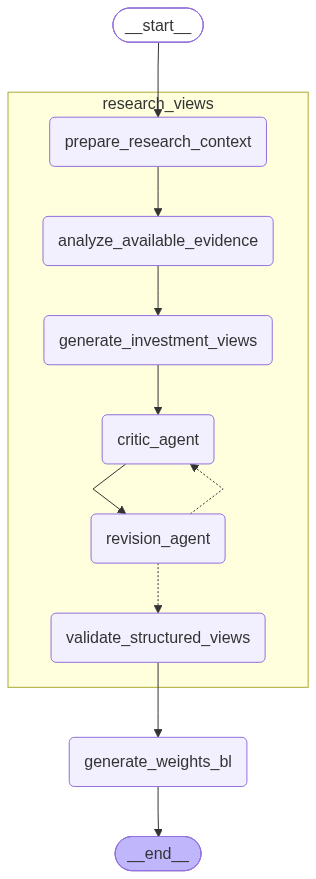

In [5]:
from IPython.display import Image, display
class NotebookState(TypedDict, total=False):
    context: ResearchContext
    result: ResearchResult
    stages: list[str]
    weights: dict[str, float]
    bl_result: dict


def generate_weights_bl(state: NotebookState):
    views_df = pd.DataFrame([view.model_dump() for view in state['result'].views.views])
    bl_result = generate_bl_allocation(
        views_df, state['result'].context, data, max_annual_alpha=MAX_ANNUAL_ALPHA,
    )
    return {
        'weights': bl_result['weights'], 'bl_result': bl_result,
        'stages': [*state['stages'], 'generate_weights_bl'],
    }


research_graph = build_research_graph(
    feedback_enabled=True, max_revision_cycles=MAX_REVISION_CYCLES,
)
builder = StateGraph(NotebookState)
builder.add_node('research_views', research_graph)
builder.add_node('generate_weights_bl', generate_weights_bl)
builder.add_edge(START, 'research_views')
builder.add_edge('research_views', 'generate_weights_bl')
builder.add_edge('generate_weights_bl', END)
workflow = builder.compile()
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))


## 5. Invoke and inspect feedback
**This cell makes paid LLM calls**, then runs deterministic validation and BL optimization. It has not been run. Malformed feedback or invented references are errors, not fallback results.

In [6]:
final_state = workflow.invoke({'context': context})
research_result = final_state['result']
print('Stages:', ' -> '.join(final_state['stages']))
print('Revision cycles:', research_result.revision_cycles)
for warning in research_result.warnings:
    print('WARNING:', warning)
print('Original proposals:')
display(pd.DataFrame([v.model_dump() for v in research_result.original_views.views]))
for cycle in research_result.feedback:
    print(f'Cycle {cycle.cycle}: {cycle.revision.summary}')
    display(pd.DataFrame([item.model_dump() for item in cycle.critic.critiques]))
    display(pd.DataFrame([v.model_dump() for v in cycle.revision.views]))
print('Validated final views:')
display(pd.DataFrame([v.model_dump() for v in research_result.views.views]))



RUNNING BLACK-LITTERMAN RECIPE: research_views_bl
Description: Research strength mapped to explicit annual prior-relative alpha targets.

📦 Universe: 4 assets - AAPL, MSFT, JPM, BND
⚙️  Parameters: tau=0.05, risk_aversion=1.0, rf=0.02, cov_lookback_years=5

📊 BOTTOM-UP VIEWS

  View 1 (Absolute): Apple's earnings estimate revisions show a consistent decline over both the 21-day (-3.86%) and 63-day (-1.76%) periods, indicating weakening earnings expectations. This consistent negative trend in EPS revisions supports a negative view on the stock based on the hypothesis to favor negative views when earnings expectations decline consistently.
    AAPL → 0.37% (confidence: 0.80)

  View 2 (Absolute): JPMorgan's earnings estimate revisions show a small positive revision over the recent 21-day period (+0.12%) and a more substantial positive revision over the 63-day period (+2.84%). This consistent upward trend in earnings expectations supports a positive view on the stock in line with the hyp

,asset,direction,magnitude,confidence,rationale,evidence_cited
0,AAPL,negative,0.6,0.80,Apple's earnings estimate revisions show a con...,"[AAPL.eps_change_21, AAPL.eps_change_63]"
1,MSFT,neutral,0.0,0.70,Microsoft's earnings estimate revisions are mi...,"[MSFT.eps_change_21, MSFT.eps_change_63]"
2,JPM,positive,0.5,0.75,JPMorgan's earnings estimate revisions show a ...,"[JPM.eps_change_21, JPM.eps_change_63]"
3,BND,neutral,0.0,0.90,Earnings estimate revisions are not applicable...,"[BND.eps_change_21, BND.eps_change_63]"


Cycle 1: The views are maintained as originally proposed, with confidence levels appropriate to the consistency and magnitude of earnings estimate revisions. Negative revisions for AAPL justify a negative view; mixed signals for MSFT warrant neutrality; positive revisions for JPM support a positive view; and lack of EPS data for BND leads to a neutral stance.


,view_index,classification,recommendation,evidence_quality,contradictions,materiality,redundancy,confidence_assessment,evidence_cited
0,0,SUPPORTED,KEEP,Moderate - EPS changes are synthetic but consi...,None apparent in the evidence cited.,Material - The consistent negative revisions o...,No redundancy with other views; unique to AAPL.,Confidence of 0.8 is reasonable given consiste...,"[AAPL.eps_change_21, AAPL.eps_change_63]"
1,1,SUPPORTED,KEEP,Moderate - EPS changes are synthetic and show ...,No direct contradictions but evidence is mixed...,Materiality is limited due to small magnitude ...,No redundancy; specific to MSFT.,Confidence of 0.7 is appropriate given the wea...,"[MSFT.eps_change_21, MSFT.eps_change_63]"
2,2,SUPPORTED,KEEP,Moderate - EPS changes are synthetic but show ...,No contradictions in the evidence cited.,Material - Positive revisions over both 21 and...,No redundancy; unique to JPM.,Confidence of 0.75 is justified given consiste...,"[JPM.eps_change_21, JPM.eps_change_63]"
3,3,SUPPORTED,KEEP,"High - EPS revisions not applicable for BND, w...",None; no EPS data for BND.,Material - Lack of EPS data justifies neutral ...,No redundancy; unique to BND.,High confidence (0.9) justified due to clear l...,"[BND.eps_change_21, BND.eps_change_63]"


,asset,direction,magnitude,confidence,rationale,evidence_cited
0,AAPL,negative,0.6,0.80,Apple's earnings estimate revisions show a con...,"[AAPL.eps_change_21, AAPL.eps_change_63]"
1,MSFT,neutral,0.0,0.70,Microsoft's earnings estimate revisions are mi...,"[MSFT.eps_change_21, MSFT.eps_change_63]"
2,JPM,positive,0.5,0.75,JPMorgan's earnings estimate revisions show a ...,"[JPM.eps_change_21, JPM.eps_change_63]"
3,BND,neutral,0.0,0.90,Earnings estimate revisions are not applicable...,"[BND.eps_change_21, BND.eps_change_63]"


Validated final views:


,asset,direction,magnitude,confidence,rationale,evidence_cited
0,AAPL,negative,0.6,0.80,Apple's earnings estimate revisions show a con...,"[AAPL.eps_change_21, AAPL.eps_change_63]"
1,MSFT,neutral,0.0,0.70,Microsoft's earnings estimate revisions are mi...,"[MSFT.eps_change_21, MSFT.eps_change_63]"
2,JPM,positive,0.5,0.75,JPMorgan's earnings estimate revisions show a ...,"[JPM.eps_change_21, JPM.eps_change_63]"
3,BND,neutral,0.0,0.90,Earnings estimate revisions are not applicable...,"[BND.eps_change_21, BND.eps_change_63]"


## 6. Portfolio Allocation: Prior vs Black-Litterman
Same BL implementation and allocation shape as the original notebook, using only the final validated views.

In [7]:
weights = final_state['weights']
for asset, weight in weights.items():
    print(f'{asset}: {weight:.2%}')
print(f'Total: {sum(weights.values()):.2%}')
allocation = pd.DataFrame(final_state['bl_result']['allocation'])
display(allocation)
display(pd.DataFrame(final_state['bl_result']['recipe']['bottom_up_views']))
print(final_state['bl_result']['calibration'])

import plotly.graph_objects as go
fig = go.Figure()
fig.add_bar(x=allocation['ticker'], y=100 * allocation['priorWeight'], name='Prior Weight', marker_color='#f59e0b')
fig.add_bar(x=allocation['ticker'], y=100 * allocation['blWeight'], name='BL Weight', marker_color='#60a5fa')
fig.update_layout(title='Portfolio Allocation: Prior vs Black-Litterman', barmode='group', yaxis_title='Weight (%)', template='plotly_dark')
fig.show()


AAPL: 100.00%
MSFT: 0.00%
JPM: 0.00%
BND: 0.00%
Total: 100.00%


,ticker,priorWeight,blWeight
0,AAPL,0.488656,1.0
1,MSFT,0.418848,0.0
2,JPM,0.078534,0.0
3,BND,0.013962,0.0


,type,asset,expected_return,confidence,label
0,absolute,AAPL,0.003739,0.80,Apple's earnings estimate revisions show a con...
1,absolute,JPM,0.033698,0.75,JPMorgan's earnings estimate revisions show a ...


{'max_annual_alpha': 0.05, 'horizon': 'annualized, following the existing 252-observation covariance convention', 'target': 'market-implied prior + direction_sign * magnitude * max_annual_alpha', 'confidence': 'existing runner Omega = tau * asset_variance / confidence', 'omitted_assets': ['MSFT', 'BND'], 'note': "Illustrative calibration, not an empirically estimated return forecast. Uses the application's existing prior/risk-free conventions unchanged. Market caps and ETF NAV proxies are static, not historical estimates."}
